In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)


## **Loading the dataset**

In [2]:
df = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep = '\t')

print(f'Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns.')

Dataset shape: 3150 rows and 5 columns.


In [3]:
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


## **Exploratory Data Analysis**

In [4]:
print(f'Shape: {df.shape}')   #checl if shape is 3150 and 5, instead of 3150 and 6

Shape: (3150, 5)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [6]:
df.describe()

,rating,feedback
count,3150.000000,3150.000000
mean,4.463175,0.918413
std,1.068506,0.273778
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


In [7]:
#Check for missing values
df.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0


In [8]:
#Drop the null record
df.dropna(inplace = True)

In [9]:
print(f"Dataset shape after dropping null values: {df.shape}")

Dataset shape after dropping null values: (3149, 5)


In [10]:
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


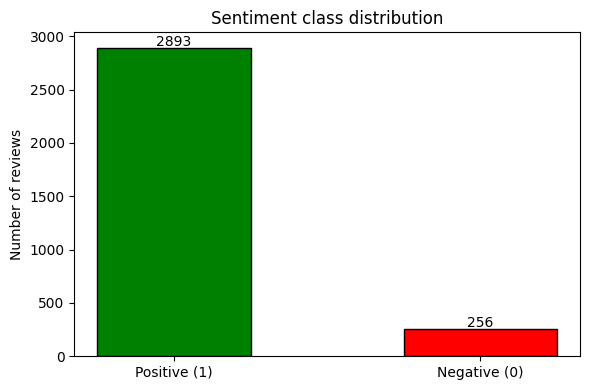

In [11]:
#Sentiment class distribution
counts = df['feedback'].value_counts()

plt.figure(figsize = (6, 4))
plt.bar(['Positive (1)', 'Negative (0)'], counts.values, color = ['green', 'red'], edgecolor = 'black', width = 0.5)
plt.title('Sentiment class distribution')
plt.ylabel('Number of reviews')
for i, v in enumerate(counts.values):
  plt.text(i, v + 20, str(v), ha = 'center')
plt.tight_layout()
plt.show()

In [12]:
print(f'Positive reviews: {counts[1]} ({counts[1]/len(df)*100:.1f}%)')
print(f'Positive reviews: {counts[0]} ({counts[0]/len(df)*100:.1f}%)')

Positive reviews: 2893 (91.9%)
Positive reviews: 256 (8.1%)


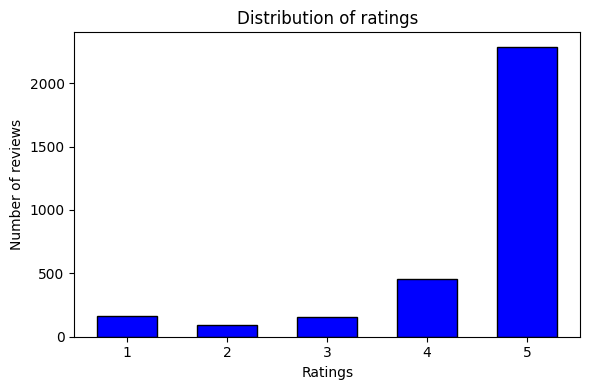

In [13]:
#Rating distribution
rating_counts = df['rating'].value_counts().sort_index()

plt.figure(figsize = (6, 4))
plt.bar(rating_counts.index, rating_counts.values, color = 'blue', edgecolor = 'black', width = 0.6)
plt.title('Distribution of ratings')
plt.xlabel('Ratings')
plt.ylabel('Number of reviews')
plt.xticks([1,2,3,4,5])
plt.tight_layout()
plt.show()

In [14]:
#Review length analysis
df['length'] = df['verified_reviews'].apply(len)

pos_avg = df[df['feedback'] == 1]['length'].mean()
neg_avg = df[df['feedback'] == 0]['length'].mean()

print(f'Average length - Positive reviews: {pos_avg:.1f} characters')
print(f'Average length - Negative reviews: {neg_avg:.1f} characters')

if neg_avg > pos_avg:
  print('\nNegative reviews tend to be longer on average')
else:
  print('\nPositive reviews tend to be longer on average')

Average length - Positive reviews: 124.7 characters
Average length - Negative reviews: 216.1 characters

Negative reviews tend to be longer on average


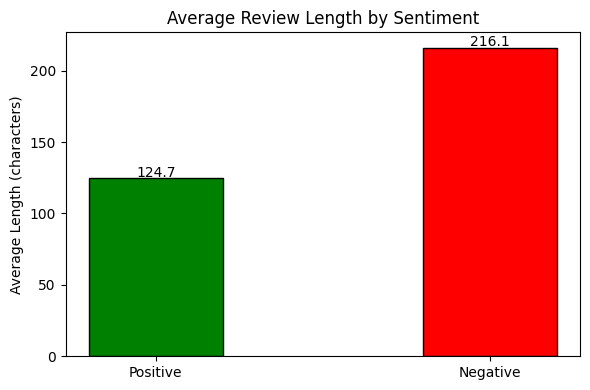

In [15]:
# Bar chart
plt.figure(figsize=(6, 4))
plt.bar(['Positive', 'Negative'], [pos_avg, neg_avg],
        color=['green', 'red'], edgecolor='black', width=0.4)
plt.title('Average Review Length by Sentiment')
plt.ylabel('Average Length (characters)')
for i, v in enumerate([pos_avg, neg_avg]):
    plt.text(i, v + 1, f'{v:.1f}', ha='center')
plt.tight_layout()
plt.show()

## **Data Preprocessing**

In [16]:
def clean_text(text):
  #remove url, html, punctuation, extra white space
  text = str(text).lower()
  text = re.sub(r'http\S+|www|S+', '', text)
  text = re.sub(r'<.*?>', '', text)
  text = re.sub(r'[^a-z\s]', '', text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

In [17]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))

def remove_stopwords_and_lemmatize(text):
  #tokenise, remove stopwords, lemmatize
  tokens = word_tokenize(text)
  tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in STOP_WORDS]
  return ' '.join(tokens)

In [18]:
#Apply both functions

df['cleaned_review'] = df['verified_reviews'].apply(clean_text)
df['cleaned_review'] = df['cleaned_review'].apply(remove_stopwords_and_lemmatize)

#Before vs After comparison
print('before vs after preprocessing (3 samples)')
for i in range (3):
  print(f'\n[{i+1}] Original: {df['verified_reviews'].iloc[i]}')
  print(f'Cleaned: {df['cleaned_review'].iloc[i]}')

before vs after preprocessing (3 samples)

[1] Original: Love my Echo!
Cleaned: love echo

[2] Original: Loved it!
Cleaned: loved

[3] Original: Sometimes while playing a game, you can answer a question correctly but Alexa says you got it wrong and answers the same as you.  I like being able to turn lights on and off while away from home.
Cleaned: sometimes playing game answer question correctly alexa say got wrong answer like able turn light away home


## **Text Visualization**

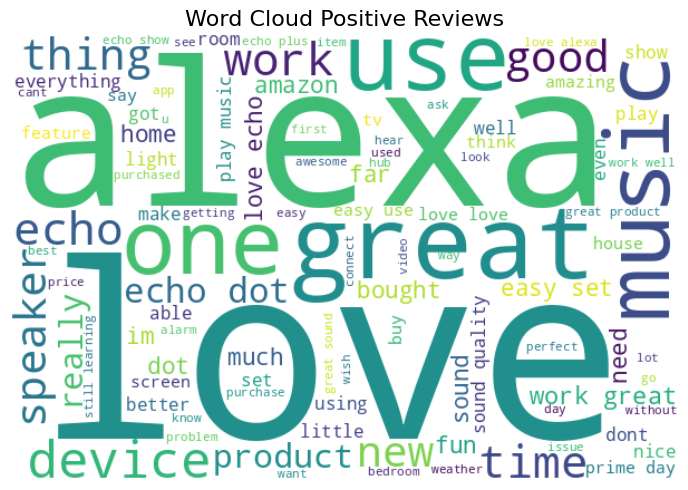

In [19]:
#Word Cloud positive reviews
pos_text = ' '.join(df[df['feedback'] == 1]['cleaned_review'])

wc_pos = WordCloud(width = 600, height = 400, background_color = 'white', max_words = 100).generate(pos_text)

plt.figure(figsize = (12, 5))
plt.imshow(wc_pos, interpolation = 'bilinear')
plt.axis('off')
plt.title('Word Cloud Positive Reviews', fontsize = 16)
plt.tight_layout()
plt.show()

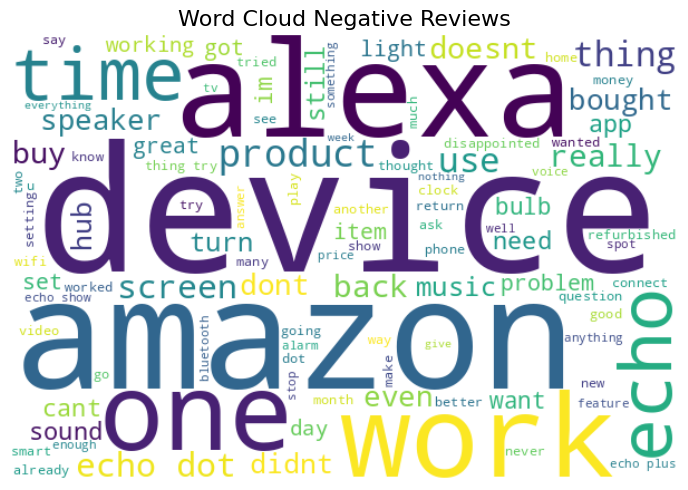

In [20]:
#Word cloud negative reviews
neg_text = ' '.join(df[df['feedback'] == 0]['cleaned_review'])

wc_neg = WordCloud(width = 600, height = 400, background_color = 'white', max_words = 100).generate(neg_text)

plt.figure(figsize = (12, 5))
plt.imshow(wc_neg, interpolation = 'bilinear')
plt.axis('off')
plt.title('Word Cloud Negative Reviews', fontsize = 16)
plt.tight_layout()
plt.show()

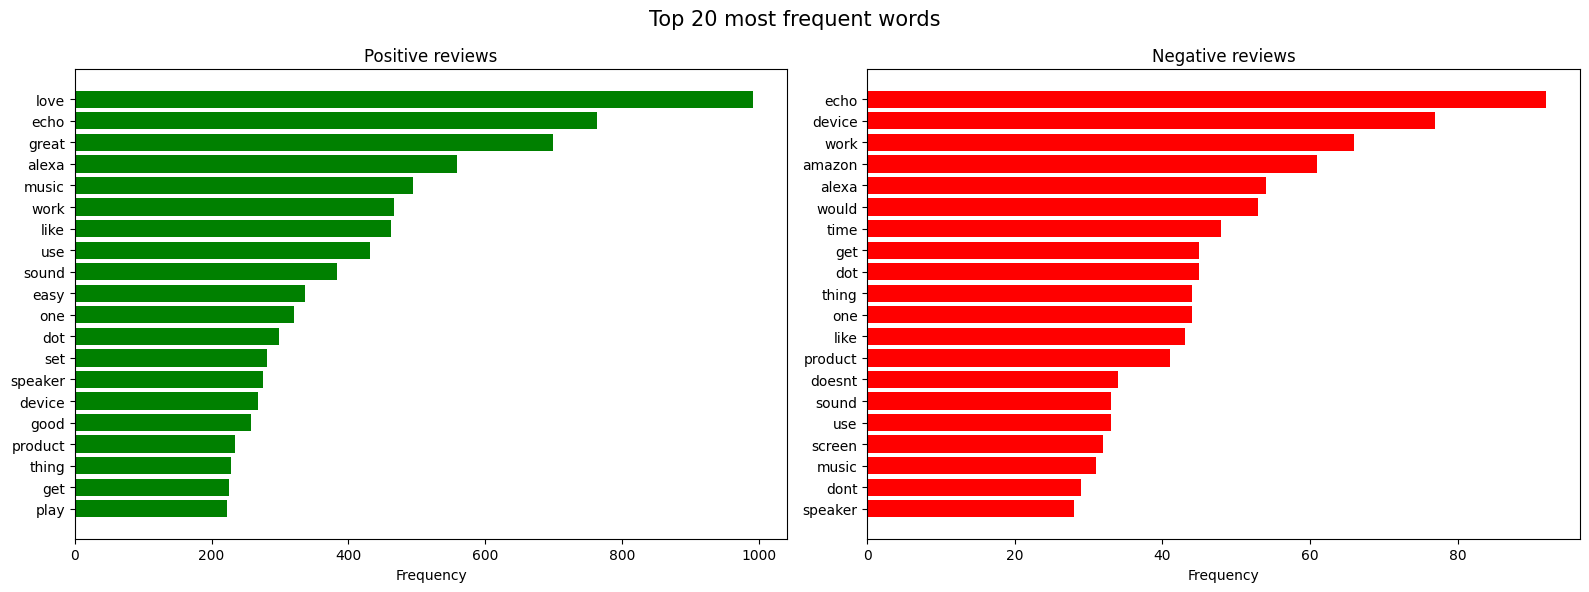

In [21]:
from collections import Counter

def top_words(text, n = 20):
  words = text.split()
  return pd.DataFrame(Counter(words).most_common(n), columns = ['Word', 'Count'])

pos_freq = top_words(pos_text)
neg_freq = top_words(neg_text)

fig, axes = plt.subplots(1, 2, figsize = (16, 6))
fig.suptitle('Top 20 most frequent words', fontsize = 15)

axes[0].barh(pos_freq['Word'][::-1], pos_freq['Count'][::-1], color = 'green')
axes[0].set_title('Positive reviews')
axes[0].set_xlabel('Frequency')

axes[1].barh(neg_freq['Word'][::-1], neg_freq['Count'][::-1], color = 'red')
axes[1].set_title('Negative reviews')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## **Feature Extraction**

In [22]:
X = df['cleaned_review']
y = df['feedback']

tfidf = TfidfVectorizer(max_features = 5000, ngram_range = (1, 2))
X_tfidf = tfidf.fit_transform(X)

print(f'Feature matrix shape: {X_tfidf.shape}')
print(f' {X_tfidf.shape[0]} reviews  x  {X_tfidf.shape[1]} TF-IDF features')
print(f'\nTarget distribution: \n{y.value_counts().rename({1:'Positive', 0:'Negative'})}')

Feature matrix shape: (3149, 5000)
 3149 reviews  x  5000 TF-IDF features

Target distribution: 
feedback
Positive    2893
Negative     256
Name: count, dtype: int64


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size = 0.2, random_state = 42, stratify = y)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

print(f'\nTrain sentiment distribution: \n{pd.Series(y_train).value_counts().rename({1:'Positive', 0:'Negative'})}')
print(f'\nTest sentiment distribution: \n{pd.Series(y_test).value_counts().rename({1:'Positive', 0:'Negative'})}')


Training set: 2519 samples
Test set: 630 samples

Train sentiment distribution: 
feedback
Positive    2314
Negative     205
Name: count, dtype: int64

Test sentiment distribution: 
feedback
Positive    579
Negative     51
Name: count, dtype: int64


## **Model Training and Evaluation**

In [31]:
#Model 1: Logistic Regression
lr = LogisticRegression(max_iter = 1000, random_state = 42, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('Model 1: Logistic Regression: ')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%')
print()
print(classification_report(y_test, y_pred_lr, target_names = ['Negative', 'Positive']))

Model 1: Logistic Regression: 
Accuracy: 92.54%

              precision    recall  f1-score   support

    Negative       0.53      0.69      0.60        51
    Positive       0.97      0.95      0.96       579

    accuracy                           0.93       630
   macro avg       0.75      0.82      0.78       630
weighted avg       0.94      0.93      0.93       630



In [32]:
#Model 2: Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print('Model 2: Naive Bayes: ')
print(f'Accuracy: {accuracy_score(y_test, y_pred_nb)*100:.2f}%')
print()
print(classification_report(y_test, y_pred_nb, target_names = ['Negative', 'Positive']))

Model 2: Naive Bayes: 
Accuracy: 91.90%

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        51
    Positive       0.92      1.00      0.96       579

    accuracy                           0.92       630
   macro avg       0.46      0.50      0.48       630
weighted avg       0.84      0.92      0.88       630



In [33]:
#Model 3: Support Vector Machine
svm = LinearSVC(random_state = 42, max_iter = 2000, class_weight='balanced')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print('Model 3: Support Vector Machine: ')
print(f'Accuracy: {accuracy_score(y_test, y_pred_svm)*100:.2f}%')
print()
print(classification_report(y_test, y_pred_svm, target_names = ['Negative', 'Positive']))

Model 3: Support Vector Machine: 
Accuracy: 91.43%

              precision    recall  f1-score   support

    Negative       0.48      0.57      0.52        51
    Positive       0.96      0.94      0.95       579

    accuracy                           0.91       630
   macro avg       0.72      0.76      0.74       630
weighted avg       0.92      0.91      0.92       630



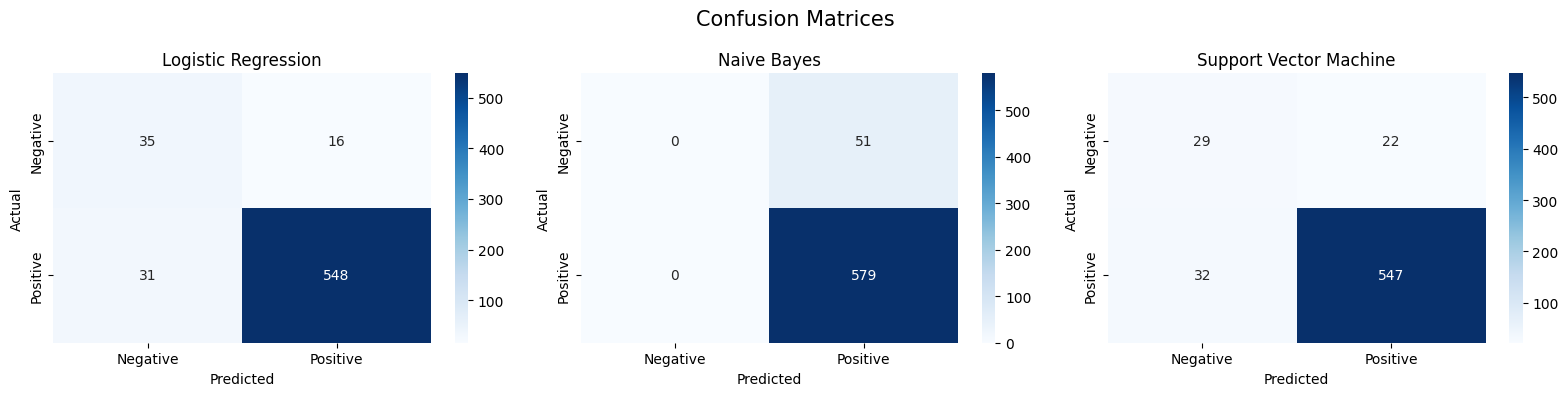

In [34]:
#Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize = (16, 4))
fig.suptitle('Confusion Matrices', fontsize = 15)

models_info = [
    ('Logistic Regression', y_pred_lr),
    ('Naive Bayes', y_pred_nb),
    ('Support Vector Machine', y_pred_svm),
]

for ax, (name, y_pred) in zip(axes, models_info):
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', ax = ax, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
  ax.set_title(name)
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_scores  (y_true, y_pred, name):
  return{
      'Model': name,
      'Accuracy': round(accuracy_score(y_true, y_pred)*100, 2),
      'Precision': round(precision_score(y_true, y_pred, average = 'weighted')*100, 2),
      'Recall': round(recall_score(y_true, y_pred, average = 'weighted')*100, 2),
      'F1-Score': round(f1_score(y_true, y_pred, average = 'weighted')*100, 2),
  }

results = pd.DataFrame([
    get_scores(y_test, y_pred_lr, 'Logistic Regression'),
    get_scores(y_test, y_pred_nb, 'Naive Bayes'),
    get_scores(y_test, y_pred_svm, 'Support Vector Machine'),
])
results.set_index('Model', inplace = True)

print('Model comparison table (in %):')
print(results.to_string())

Model comparison table (in %):
                        Accuracy  Precision  Recall  F1-Score
Model                                                        
Logistic Regression        92.54      93.59   92.54     92.97
Naive Bayes                91.90      84.46   91.90     88.03
Support Vector Machine     91.43      92.20   91.43     91.77


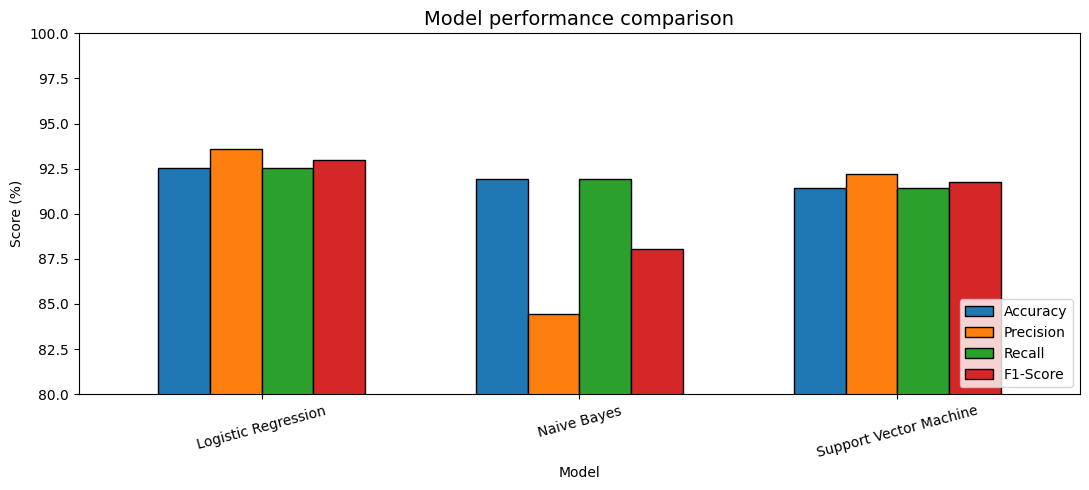

In [36]:
#Bar chart
results.plot(kind = 'bar', figsize = (11, 5), edgecolor = 'black', width = 0.65)
plt.title('Model performance comparison', fontsize = 14)
plt.ylabel('Score (%)')
plt.xticks(rotation = 15)
plt.ylim(80, 100)
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.show()

## **Test on custom input**

In [38]:
def predict_sentiment(review_text, model = lr):
  #clean a raw review and predict its sentiment
  cleaned = clean_text(review_text)
  cleaned = remove_stopwords_and_lemmatize(cleaned)
  vector = tfidf.transform([cleaned])
  pred = model.predict(vector)[0]
  label = 'Positive' if pred == 1 else 'Negative'
  print(f'Review: {review_text}')
  print(f'Sentiment: {label}')
  print('-'*60)

#Test reviews
predict_sentiment("I absolutely love my Alexa! It works perfectly every day.")
predict_sentiment("This device is terrible. It never connects to WiFi properly.")
predict_sentiment("Great sound quality and easy to set up. Highly recommend!")
predict_sentiment("Stopped working after a week. Very disappointed with the product.")
predict_sentiment("It's okay, nothing special but does what it's supposed to.")

Review: I absolutely love my Alexa! It works perfectly every day.
Sentiment: Positive
------------------------------------------------------------
Review: This device is terrible. It never connects to WiFi properly.
Sentiment: Negative
------------------------------------------------------------
Review: Great sound quality and easy to set up. Highly recommend!
Sentiment: Positive
------------------------------------------------------------
Review: Stopped working after a week. Very disappointed with the product.
Sentiment: Negative
------------------------------------------------------------
Review: It's okay, nothing special but does what it's supposed to.
Sentiment: Negative
------------------------------------------------------------
